# k-Nearest Neighbors Regression on California Housing

## Project Overview

This notebook applies instance-based regression to the California Housing dataset and studies the effects of neighborhood size, weighting, feature scaling, distance computation, and efficient hyperparameter search.

### Technical Coverage

- k-NN regression
- Distance-weighted and uniform prediction
- Train/test error analysis
- Hyperparameter selection for \(k\)
- Feature-scale sensitivity
- Manual standardization
- Min-Max scaling and standard scaling
- Custom weighted k-NN regressor
- Four distance-computation strategies
- Runtime comparison
- Efficient evaluation of many neighborhood sizes

## 1. California Housing Dataset

The target is a continuous housing value, making this a regression counterpart to the earlier k-NN classification experiments.

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
dataset = fetch_california_housing()
x = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)

print(dataset.feature_names)

print('Array shapes')
for x in [X_train, X_test, y_train, y_test]:
  print(x.shape)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Array shapes
(16512, 8)
(4128, 8)
(16512,)
(4128,)


## 2. Baseline Distance-Weighted k-NN

A three-neighbor distance-weighted model establishes the initial test performance.

In [8]:


model = KNeighborsRegressor(n_neighbors=3, weights='distance')
model.fit(X_train, y_train)
start = time.time()
pred = model.predict(X_test)
elapsed_time = time.time()-start
print('\nElapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'mean_absolute_error: {mean_absolute_error(y_test,pred):6.4f}')
print(f'mean_squared_error: {mean_squared_error(y_test,pred):6.4f}')


Elapsed_time testing  0.031555 
mean_absolute_error: 0.8188
mean_squared_error: 1.1702


### Predicted vs. Observed Values

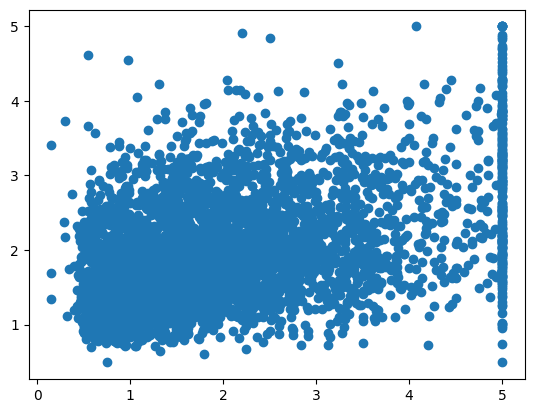

In [9]:
plt.scatter(y_test,pred)

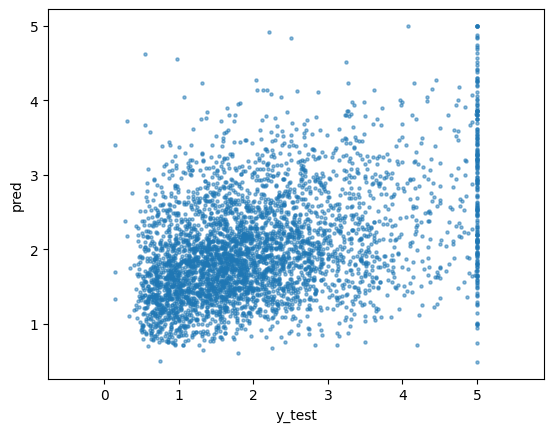

In [10]:
plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

## 3. Training-Set Behavior

With distance weighting, every training observation is its own zero-distance neighbor. The saved training result therefore reaches zero error, illustrating why training performance alone is not useful for selecting \(k\) in this setting.

mean_absolute_error: 0.0000
mean_squared_error: 0.0000


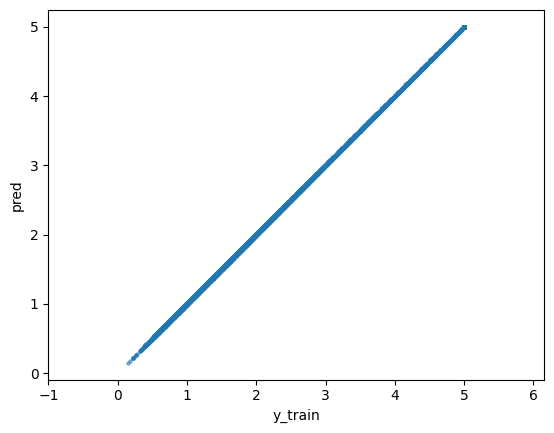

In [11]:
pred = model.predict(X_train)
print(f'mean_absolute_error: {mean_absolute_error(y_train,pred):6.4f}')
print(f'mean_squared_error: {mean_squared_error(y_train,pred):6.4f}')
plt.scatter(y_train,pred,s=5,alpha=0.5)
plt.xlabel("y_train")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

## 4. Selecting k with Distance Weighting

Neighborhood sizes from 1 through 19 are compared using held-out mean squared error.

In [12]:
for k in range(1,20):
  model = KNeighborsRegressor(n_neighbors=k, weights='distance')
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  print(f'{k = :2}, mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')

k =  1, mean_squared_error: 1.575291
k =  2, mean_squared_error: 1.279349
k =  3, mean_squared_error: 1.170160
k =  4, mean_squared_error: 1.129180
k =  5, mean_squared_error: 1.110818
k =  6, mean_squared_error: 1.096517
k =  7, mean_squared_error: 1.090653
k =  8, mean_squared_error: 1.085434
k =  9, mean_squared_error: 1.083386
k = 10, mean_squared_error: 1.082650
k = 11, mean_squared_error: 1.082743
k = 12, mean_squared_error: 1.088456
k = 13, mean_squared_error: 1.093088
k = 14, mean_squared_error: 1.096218
k = 15, mean_squared_error: 1.096390
k = 16, mean_squared_error: 1.099577
k = 17, mean_squared_error: 1.104355
k = 18, mean_squared_error: 1.107695
k = 19, mean_squared_error: 1.112356


### Best Raw-Feature Model from the Initial Sweep

mean_squared_error: 1.082650


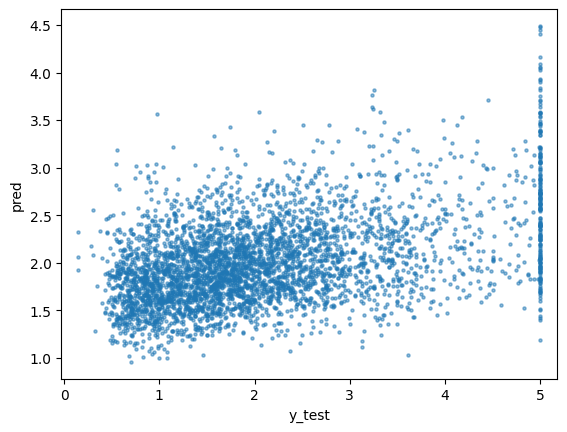

In [13]:
model = KNeighborsRegressor(n_neighbors=10, weights='distance')
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f'mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')
plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

## 5. Uniform vs. Distance-Weighted Regression

The same neighborhood range is evaluated without distance weighting.

In [14]:
for k in range(1,20):
  model = KNeighborsRegressor(n_neighbors=k)
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  print(f'{k = :2}, mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')

k =  1, mean_squared_error: 1.575291
k =  2, mean_squared_error: 1.299088
k =  3, mean_squared_error: 1.191509
k =  4, mean_squared_error: 1.155374
k =  5, mean_squared_error: 1.142019
k =  6, mean_squared_error: 1.127698
k =  7, mean_squared_error: 1.122718
k =  8, mean_squared_error: 1.117769
k =  9, mean_squared_error: 1.116705
k = 10, mean_squared_error: 1.116952
k = 11, mean_squared_error: 1.117942
k = 12, mean_squared_error: 1.125403
k = 13, mean_squared_error: 1.131803
k = 14, mean_squared_error: 1.136268
k = 15, mean_squared_error: 1.135816
k = 16, mean_squared_error: 1.139333
k = 17, mean_squared_error: 1.144984
k = 18, mean_squared_error: 1.148571
k = 19, mean_squared_error: 1.154627


## 6. Why Feature Scaling Matters for k-NN

Because nearest neighbors are defined through distances, features with larger numerical scales can dominate the neighborhood calculation. The original feature means and standard deviations are inspected before scaling.

In [15]:
print(np.mean(X_train,axis=0))
print(np.std(X_train,axis=0))

[ 3.86431002e+00  2.86111313e+01  5.40409167e+00  1.09271995e+00
  1.42974727e+03  3.06495317e+00  3.56250388e+01 -1.19563364e+02]
[1.89106975e+00 1.26270963e+01 2.19709476e+00 4.30028072e-01
 1.12575691e+03 1.06329549e+01 2.13207606e+00 2.00363871e+00]


### Manual Standardization

In [16]:
mean_tr = np.mean(X_train,axis=0)
std_tr = np.std(X_train,axis=0)
X_train = (X_train - mean_tr)/ std_tr
X_test = (X_test - mean_tr)/ std_tr

In [17]:
for k in range(1,20):
  model = KNeighborsRegressor(n_neighbors=k, weights='distance')
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  print(f'{k = :2}, mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')

k =  1, mean_squared_error: 0.646689
k =  2, mean_squared_error: 0.506234
k =  3, mean_squared_error: 0.463306
k =  4, mean_squared_error: 0.446676
k =  5, mean_squared_error: 0.433897
k =  6, mean_squared_error: 0.429674
k =  7, mean_squared_error: 0.427569
k =  8, mean_squared_error: 0.420690
k =  9, mean_squared_error: 0.420470
k = 10, mean_squared_error: 0.419446
k = 11, mean_squared_error: 0.415524
k = 12, mean_squared_error: 0.414660
k = 13, mean_squared_error: 0.415798
k = 14, mean_squared_error: 0.415604
k = 15, mean_squared_error: 0.415278
k = 16, mean_squared_error: 0.415995
k = 17, mean_squared_error: 0.415877
k = 18, mean_squared_error: 0.416034
k = 19, mean_squared_error: 0.416809


mean_squared_error: 0.415278


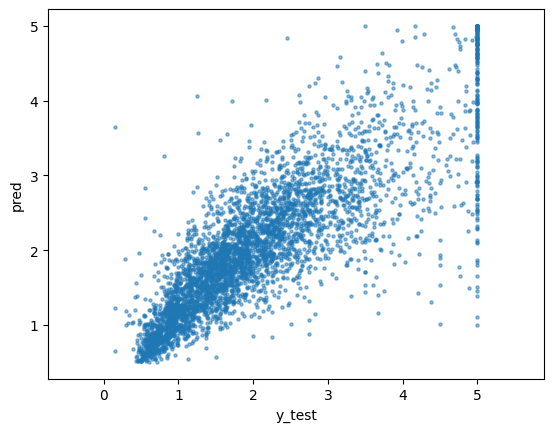

In [18]:
model = KNeighborsRegressor(n_neighbors=15, weights='distance')
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f'mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')
plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

## 7. Min-Max Scaling vs. Standard Scaling

Both transformations are fitted on the training data and applied to the test data. Distribution summaries are retained to show how each scaler changes the numerical representation.

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

dataset =fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.20, random_state=5361)

scaler = MinMaxScaler()
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [20]:
def print_dataset_info(x):
  print("Means:", *(f"{x:.4f}" for x in x.mean(axis=0)))
  print("Standard deviations:", *(f"{x:.4f}" for x in x.std(axis=0)))
  print("Minima:", *(f"{x:.4f}" for x in x.min(axis=0)))
  print("Maxima:", *(f"{x:.4f}" for x in x.max(axis=0)))

### Min-Max Scaled Training Data

In [21]:
print_dataset_info(X_train_minmax)

Means: 0.2320 0.5414 0.0346 0.0213 0.0400 0.0019 0.3278 0.4855
Standard deviations: 0.1304 0.2476 0.0167 0.0128 0.0316 0.0086 0.2266 0.2032
Minima: 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000
Maxima: 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000


### Standardized Training Data

In [22]:
print_dataset_info(X_train_std)

Means: -0.0000 -0.0000 -0.0000 -0.0000 0.0000 0.0000 0.0000 -0.0000
Standard deviations: 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000
Minima: -1.7791 -2.1867 -2.0745 -1.6690 -1.2674 -0.2231 -1.4470 -2.3890
Maxima: 5.8886 1.8523 57.8624 76.6786 30.4260 116.6438 2.9666 2.5321


### Min-Max Scaled Test Data

In [23]:
print_dataset_info(X_test_minmax)

Means: 0.2342 0.5442 0.0356 0.0219 0.0394 0.0019 0.3315 0.4822
Standard deviations: 0.1334 0.2434 0.0255 0.0184 0.0325 0.0075 0.2286 0.2031
Minima: 0.0000 0.0000 0.0003 -0.0012 0.0001 0.0003 0.0021 0.0051
Maxima: 1.0000 1.0000 1.0712 0.7498 0.8006 0.4821 0.9968 1.0183


### Standardized Test Data

In [24]:
print_dataset_info(X_test_std)

Means: 0.0168 0.0112 0.0567 0.0460 -0.0190 0.0027 0.0160 -0.0158
Standard deviations: 1.0227 0.9833 1.5290 1.4389 1.0292 0.8776 1.0088 0.9995
Minima: -1.7791 -2.1867 -2.0551 -1.7659 -1.2629 -0.1885 -1.4376 -2.3640
Maxima: 5.8886 1.8523 62.1298 57.0745 24.1049 56.1132 2.9525 2.6219


### Comparing Scalers Across k

In [25]:
print('Using MinMaxScaler')
for k in range(1,20):
  model = KNeighborsRegressor(n_neighbors=k, weights='distance')
  model.fit(X_train_minmax, y_train)
  pred = model.predict(X_test_minmax)
  print(f'{k = :2}, mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')

print('\nUsing StandardScaler')
for k in range(1,20):
  model = KNeighborsRegressor(n_neighbors=k, weights='distance')
  model.fit(X_train_std, y_train)
  pred = model.predict(X_test_std)
  print(f'{k = :2}, mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')


Using MinMaxScaler
k =  1, mean_squared_error: 0.593623
k =  2, mean_squared_error: 0.458620
k =  3, mean_squared_error: 0.420396
k =  4, mean_squared_error: 0.404784
k =  5, mean_squared_error: 0.391659
k =  6, mean_squared_error: 0.387768
k =  7, mean_squared_error: 0.382999
k =  8, mean_squared_error: 0.382909
k =  9, mean_squared_error: 0.381501
k = 10, mean_squared_error: 0.380904
k = 11, mean_squared_error: 0.381012
k = 12, mean_squared_error: 0.380764
k = 13, mean_squared_error: 0.382597
k = 14, mean_squared_error: 0.382740
k = 15, mean_squared_error: 0.383665
k = 16, mean_squared_error: 0.384643
k = 17, mean_squared_error: 0.386146
k = 18, mean_squared_error: 0.387076
k = 19, mean_squared_error: 0.387976

Using StandardScaler
k =  1, mean_squared_error: 0.646689
k =  2, mean_squared_error: 0.506234
k =  3, mean_squared_error: 0.463306
k =  4, mean_squared_error: 0.446676
k =  5, mean_squared_error: 0.433897
k =  6, mean_squared_error: 0.429674
k =  7, mean_squared_error: 0.4275

### Best Saved Min-Max Model

mean_squared_error: 0.380764


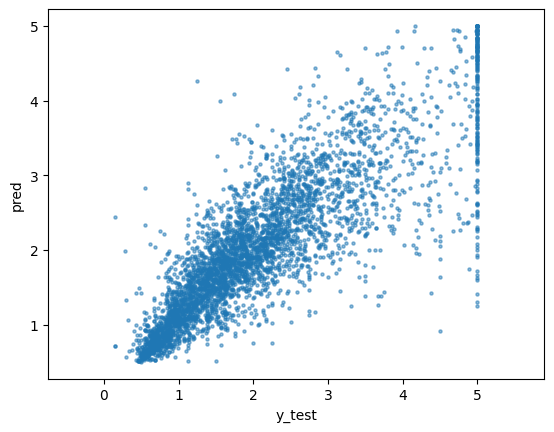

In [26]:
model = KNeighborsRegressor(n_neighbors=12, weights='distance')
model.fit(X_train_minmax, y_train)
pred = model.predict(X_test_minmax)
print(f'mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')
plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

## 8. Weighted k-NN Regression Implemented from Scratch

A custom regressor is retained with four alternative strategies for computing distances:

1. loop over test observations,
2. loop over attributes,
3. fully vectorized matrix identity,
4. broadcasting over train/test pairs.

All four methods use the same inverse-distance weighted prediction rule.

> **Memory note:** the broadcasting version constructs a large three-dimensional intermediate array and is not suitable for large datasets.

In [27]:
dataset = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.20, random_state=5361)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
class knn_regressor:

    def __init__(self,k=5):
      self.k = k
      return

    def fit(self,X_train,y_train):
      self.X_train = X_train.copy()
      self.y_train = y_train.copy()

    def predict(self,X_test):
      dist = np.zeros((self.X_train.shape[0], X_test.shape[0]))
      # Looping over test examples
      for i in range(X_test.shape[0]):
        dist[:,i] = np.sum((self.X_train - X_test[i])**2,axis=1)
      nn = np.argpartition(dist,self.k,axis=0)[:self.k]
      dist = np.sqrt(dist[nn,np.tile(np.arange(nn.shape[1]),(nn.shape[0],1))])
      w = 1/(dist+0.00001)
      w = w/np.sum(w,axis=0)
      pred = np.sum(self.y_train[nn]*w,axis=0)
      return pred

    def predict2(self,X_test):
      # Idea: build a distance matrix dist of shape (X_train.shape[0], X_test.shape[0])
      # Where dist[i,j] is the distance from X_train[i] to X_test[j]
      dist = 0
      # Looping over attributes
      for i in range(X_test.shape[1]):
        dist += (self.X_train[:,i:i+1] - X_test[:,i:i+1].T)**2
      nn = np.argpartition(dist,self.k,axis=0)[:self.k]
      dist = np.sqrt(dist[nn,np.tile(np.arange(nn.shape[1]),(nn.shape[0],1))])
      w = 1/(dist+0.00001)
      w = w/np.sum(w,axis=0)
      pred = np.sum(self.y_train[nn]*w,axis=0)
      return pred

    def predict3(self,X_test):
      # Idea: build a distance matrix dist of shape (X_train.shape[0], X_test.shape[0])
      # Where dist[i,j] is the distance from X_train[i] to X_test[j]
      # No loops; we will use the fact that (X_train[i] - X_test[j])**2 = X_train[i]**2 + X_test[j]**2 - 2*X_train[i]*X_test[j]
      dist = np.sum(self.X_train**2,axis=1).reshape(-1,1) + np.sum(X_test**2,axis=1).reshape(1,-1) -2*np.matmul(self.X_train,X_test.T)
      nn = np.argpartition(dist,self.k,axis=0)[:self.k]
      dist = np.sqrt(dist[nn,np.tile(np.arange(nn.shape[1]),(nn.shape[0],1))])
      w = 1/(dist+0.00001)
      w = w/np.sum(w,axis=0)
      pred = np.sum(self.y_train[nn]*w,axis=0)
      return pred

    def predict4(self,X_test):
      # No loops, using broadcasting
      # It creates a very large intermediate array (X_train.shape[0],X_test.shape[0],X_train.shape[1]); it won't work for large datasets
      dist = np.sum((np.expand_dims(self.X_train,1) - X_test)**2,axis=-1)
      nn = np.argpartition(dist,self.k,axis=0)[:self.k]
      dist = np.sqrt(dist[nn,np.tile(np.arange(nn.shape[1]),(nn.shape[0],1))])
      w = 1/(dist+0.00001)
      w = w/np.sum(w,axis=0)
      pred = np.sum(self.y_train[nn]*w,axis=0)
      return pred

### Runtime and Error Comparison

In [29]:
model = knn_regressor(k=10)
model.fit(X_train,y_train)

start = time.time()
pred = model.predict(X_test)
elapsed_time = time.time()-start
print('\nElapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'mean_absolute_error: {mean_absolute_error(y_test,pred):6.4f}')
print(f'mean_squared_error: {mean_squared_error(y_test,pred):6.4f}')

start = time.time()
pred = model.predict2(X_test)
elapsed_time = time.time()-start
print('\nElapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'mean_absolute_error: {mean_absolute_error(y_test,pred):6.4f}')
print(f'mean_squared_error: {mean_squared_error(y_test,pred):6.4f}')

start = time.time()
pred = model.predict3(X_test)
elapsed_time = time.time()-start
print('\nElapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'mean_absolute_error: {mean_absolute_error(y_test,pred):6.4f}')
print(f'mean_squared_error: {mean_squared_error(y_test,pred):6.4f}')

start = time.time()
pred = model.predict4(X_test)
elapsed_time = time.time()-start
print('\nElapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'mean_absolute_error: {mean_absolute_error(y_test,pred):6.4f}')
print(f'mean_squared_error: {mean_squared_error(y_test,pred):6.4f}')


Elapsed_time testing  9.009488 
mean_absolute_error: 0.4123
mean_squared_error: 0.3809

Elapsed_time testing  5.014376 
mean_absolute_error: 0.4123
mean_squared_error: 0.3809

Elapsed_time testing  2.606970 
mean_absolute_error: 0.4123
mean_squared_error: 0.3809

Elapsed_time testing  7.212670 
mean_absolute_error: 0.4123
mean_squared_error: 0.3809


## 9. Brute-Force Search for the Best Neighborhood Size

The first approach fits and evaluates a separate scikit-learn model for every value of \(k\). Weighted and uniform formulations are both retained.

### Distance-Weighted Search

In [30]:
start = time.time()
nn = np.arange(1,51)
err = []
for k in nn:
  model = KNeighborsRegressor(n_neighbors=k, weights='distance')
  model.fit(X_train_minmax, y_train)
  pred = model.predict(X_test_minmax)
  mse = mean_squared_error(y_test,pred)
  #print(f'{k = :2}, {mse = :8.6f}')
  err.append(mse)

a = np.argmin(err)
elapsed_time = time.time()-start
print('\nElapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'Best value of k is {nn[a]}, with mse = {err[a]:8.6f}')


Elapsed_time testing  12.134123 
Best value of k is 12, with mse = 0.380764


### Uniform-Weight Search

In [31]:
start = time.time()
nn = np.arange(1,51)
err = []
for k in nn:
  model = KNeighborsRegressor(n_neighbors=k)
  model.fit(X_train_minmax, y_train)
  pred = model.predict(X_test_minmax)
  mse = mean_squared_error(y_test,pred)
  #print(f'{k = :2}, {mse = :8.6f}')
  err.append(mse)

a = np.argmin(err)
elapsed_time = time.time()-start
print('\nElapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'Best value of k is {nn[a]}, with mse = {err[a]:8.6f}')


Elapsed_time testing  12.001565 
Best value of k is 10, with mse = 0.390547


## 10. Efficient Multi-k Evaluation

Nearest neighbors are computed once up to \(k=50\). Cumulative weighted predictions then evaluate every smaller neighborhood without recomputing the complete distance search.

### Efficient Distance-Weighted Evaluation

In [32]:
start = time.time()
model = KNeighborsRegressor(weights='distance')
model.fit(X_train_minmax, y_train)
dist, ind = model.kneighbors(X_test,n_neighbors=50)
weight = dist**-1 # The weights are given by the inverse distance
pred = np.cumsum(y_train[ind]*weight,axis=1)/np.cumsum(weight,axis=1)
err = np.mean((pred - y_test.reshape(-1,1))**2,axis=0)
a = np.argmin(err)
elapsed_time = time.time()-start
print('Elapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'Best value of k is {a+1}, with mse = {err[a]:8.6f}')

Elapsed_time testing  0.329403 
Best value of k is 12, with mse = 0.380764


### Efficient Uniform-Weight Evaluation

For uniform weighting, cumulative target sums are divided by the number of neighbors included at each value of \(k\).

In [33]:
start = time.time()
model = KNeighborsRegressor(weights='distance')
model.fit(X_train_minmax, y_train)
dist, ind = model.kneighbors(X_test,n_neighbors=50)
pred = np.cumsum(y_train[ind],axis=1)/np.arange(1,ind.shape[1]+1)
err = np.mean((pred - y_test.reshape(-1,1))**2,axis=0)
a = np.argmin(err)
elapsed_time = time.time()-start
print('Elapsed_time testing  {0:.6f} '.format(elapsed_time))
print(f'Best value of k is {a+1}, with mse = {err[a]:8.6f}')

Elapsed_time testing  1.368240 
Best value of k is 10, with mse = 0.390547


## 11. Comparative Results

| Representation / Search | Best Saved k | Test MSE |
|---|---:|---:|
| Raw features, distance weighted | 10 | 1.082650 |
| Raw features, uniform | 9 | 1.116705 |
| Manually standardized, distance weighted | 12 | 0.414660 |
| Min-Max scaled, distance weighted | **12** | **0.380764** |
| StandardScaler, distance weighted | 12 | 0.414660 |
| Efficient weighted search | **12** | **0.380764** |
| Efficient uniform search | 10 | 0.390547 |

The strongest saved result comes from Min-Max scaled features with distance weighting and \(k=12\). The improvement over the raw-feature model shows the importance of scale normalization for distance-based regression.

### Custom Implementation

All four custom distance-computation strategies produce approximately the same saved error at \(k=10\):

- MAE ≈ **0.4123**
- MSE ≈ **0.3809**

The implementations differ primarily in computational strategy and memory use rather than predictive output.

## 12. Key Findings

- Feature scaling has a major effect on k-NN regression because the model is defined directly through distance.
- Min-Max scaling produces the best saved California Housing result among the tested transformations.
- Distance weighting outperforms the corresponding uniform-weight search in the saved experiment.
- Different distance-computation implementations can produce the same predictions with very different runtimes and memory requirements.
- Precomputing the nearest-neighbor ordering allows many values of \(k\) to be evaluated far more efficiently than refitting and recomputing distances independently.